In [1]:
import os
os.makedirs('charts', exist_ok=True)
print("charts folder created ✅")

charts folder created ✅


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
print("Libraries imported ✅")

Libraries imported ✅


In [3]:
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
df.head()

Shape: (9994, 21)

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year
df['Order Quarter'] = df['Order Date'].dt.quarter

df.drop_duplicates(inplace=True)

print("Data cleaned ✅")
print("Final shape:", df.shape)
df.head()

Data cleaned ✅
Final shape: (9994, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Month,Order Year,Order Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,2016,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,2016,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,2016,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,2015,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,2015,4


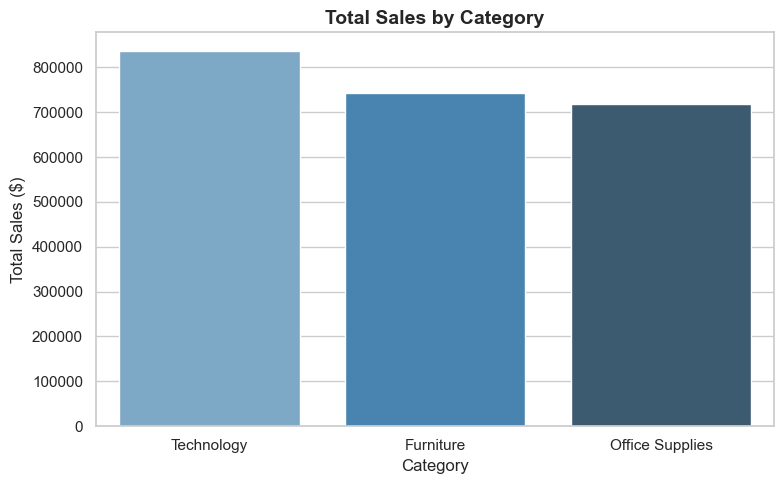

In [5]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=cat_sales.index, y=cat_sales.values, palette='Blues_d')
plt.title('Total Sales by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/sales_by_category.png')
plt.show()

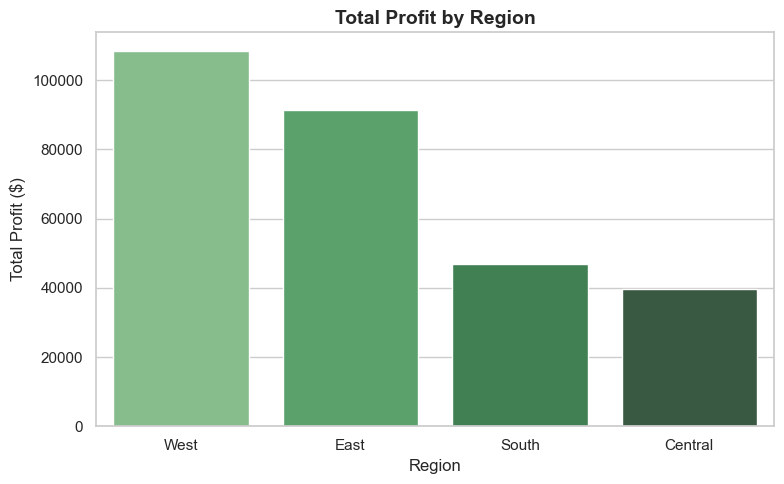

In [6]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_profit.index, y=region_profit.values, palette='Greens_d')
plt.title('Total Profit by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('charts/profit_by_region.png')
plt.show()

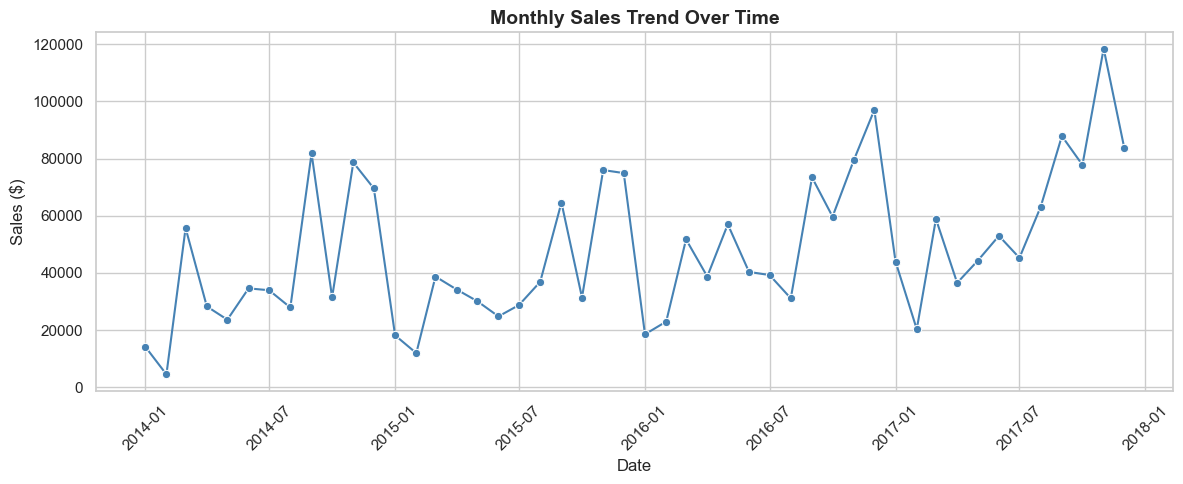

In [7]:
monthly = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(
    monthly[['Order Year', 'Order Month']].assign(day=1)
    .rename(columns={'Order Year': 'year', 'Order Month': 'month'})
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly, x='Date', y='Sales', marker='o', color='steelblue')
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png')
plt.show()

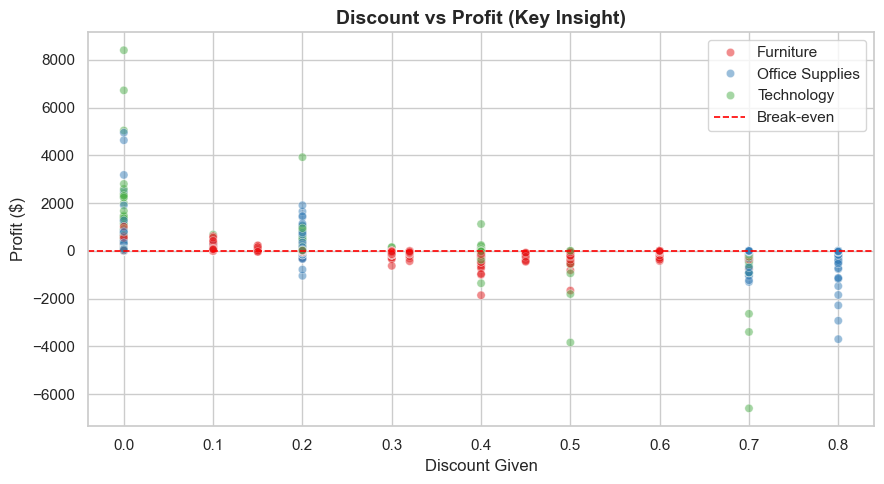

In [8]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.5,
                hue='Category', palette='Set1')
plt.axhline(0, color='red', linestyle='--', linewidth=1.2, label='Break-even')
plt.title('Discount vs Profit (Key Insight)', fontsize=14, fontweight='bold')
plt.xlabel('Discount Given')
plt.ylabel('Profit ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/discount_vs_profit.png')
plt.show()

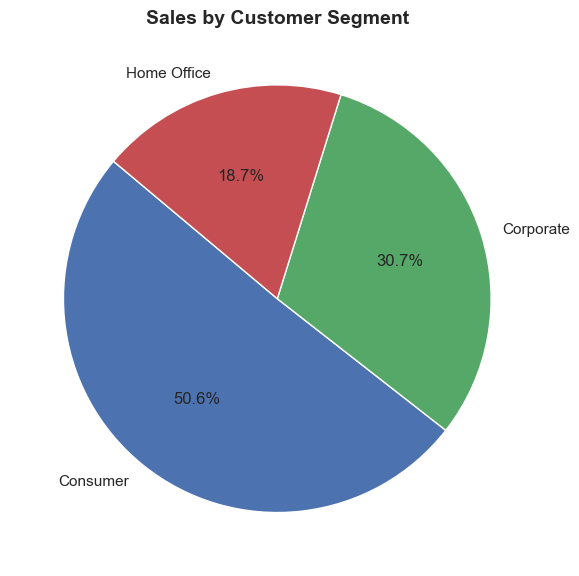

In [9]:
seg = df.groupby('Segment')['Sales'].sum()

plt.figure(figsize=(6, 6))
plt.pie(seg, labels=seg.index, autopct='%1.1f%%',
        colors=['#4C72B0', '#55A868', '#C44E52'], startangle=140)
plt.title('Sales by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/customer_segment.png')
plt.show()

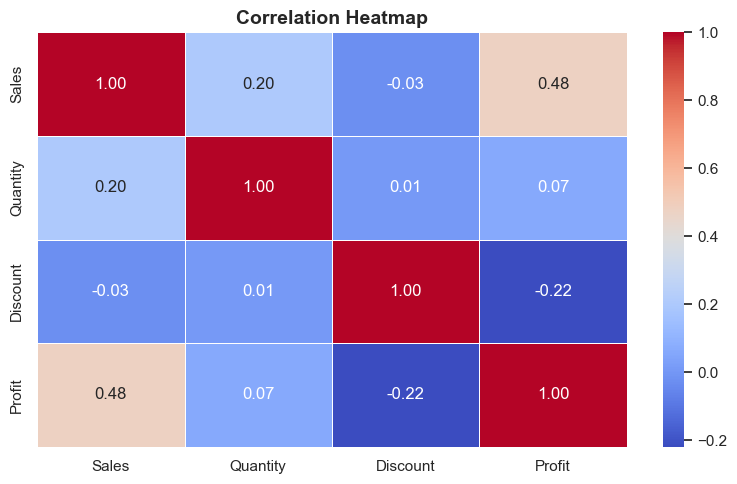

In [10]:
plt.figure(figsize=(8, 5))
corr = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png')
plt.show()

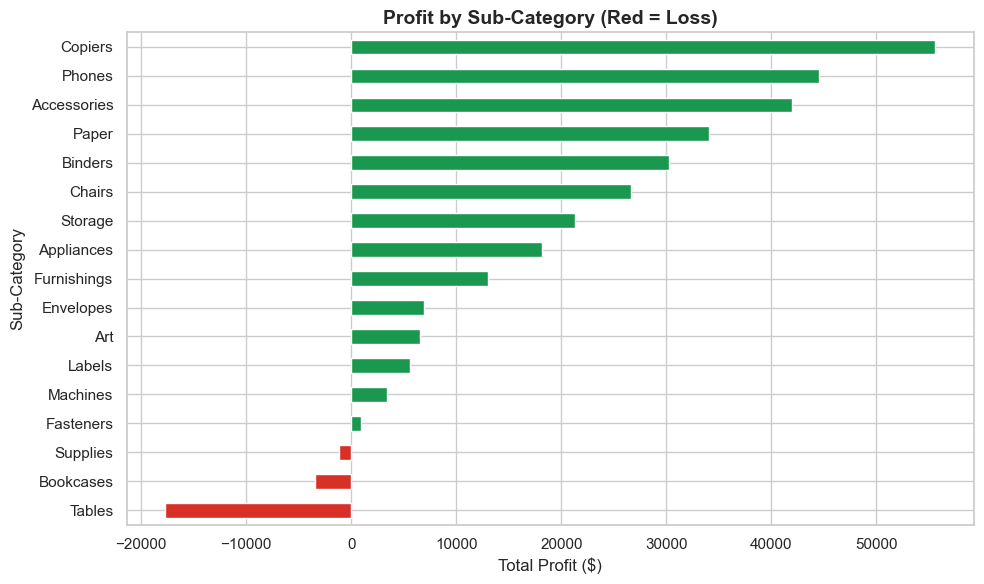

In [11]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

colors = ['#d73027' if x < 0 else '#1a9850' for x in sub_profit]
sub_profit.plot(kind='barh', color=colors, figsize=(10, 6))
plt.title('Profit by Sub-Category (Red = Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('charts/subcategory_profit.png')
plt.show()

In [12]:
print("=" * 50)
print("📊 KEY BUSINESS INSIGHTS")
print("=" * 50)

print(f"\n1. Top Category by Sales   : {cat_sales.idxmax()} (${cat_sales.max():,.0f})")
print(f"2. Most Profitable Region  : {region_profit.idxmax()} (${region_profit.max():,.0f})")

loss_orders = df[df['Profit'] < 0]
print(f"3. Loss-making orders      : {len(loss_orders)} ({len(loss_orders)/len(df)*100:.1f}% of total)")

high_discount_loss = df[(df['Discount'] >= 0.4) & (df['Profit'] < 0)]
print(f"4. High discount + loss    : {len(high_discount_loss)} orders")

best_month = monthly.loc[monthly['Sales'].idxmax()]
print(f"5. Best Sales Month        : Year {int(best_month['Order Year'])}, Month {int(best_month['Order Month'])}")

📊 KEY BUSINESS INSIGHTS

1. Top Category by Sales   : Technology ($836,154)
2. Most Profitable Region  : West ($108,418)
3. Loss-making orders      : 1871 (18.7% of total)
4. High discount + loss    : 1113 orders
5. Best Sales Month        : Year 2017, Month 11
